# H2 · Dataset collection and first look

**Kartonky × Reddit: offline vs online protest discourse, July–August 2026**

Three sources, all cleaned by the scripts in `scripts/` (see the repo README for the pipeline):

| Source | What | File |
|---|---|---|
| Kartonky archive (kartonky.propellercrew.com) | protest posters: text, city, date | `data/clean/kartonky_clean.csv` |
| Reddit submissions, 8 subreddits | posts, July–August 2026 (Pushshift dumps) | `data/clean/reddit_submissions.csv` |
| Reddit comments, 8 subreddits | comments, July–August 2026 | `data/clean/reddit_comments.csv` |

Sizes are in decimal MB (10⁶ bytes). The comments file is ~640 MB, so it is read in chunks and only the needed columns are loaded.

In [1]:
from collections import Counter
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA, CLEAN = ROOT / "data", ROOT / "data" / "clean"
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_colwidth", 70)
pd.set_option("display.width", 180)

# Subreddit groups used throughout (chosen in scripts/reddit/analyze_scan.py)
GROUPS = {
    "reddit_ukr": "Ukrainian communities", "RedditUATalks": "Ukrainian communities", "Kyiv": "Ukrainian communities",
    "ukraine": "Ukraine-focused (EN)", "UkrainianConflict": "Ukraine-focused (EN)",
    "worldnews": "International", "europe": "International", "UkraineRussiaReport": "International",
}
GROUP_ORDER = ["Ukrainian communities", "Ukraine-focused (EN)", "International"]
FEDOROV = r"fedorov|федоров"          # the July 2026 protests were about Fedorov's dismissal
PROTEST_START = pd.Timestamp("2026-07-16")

# Chart style: thin marks, recessive hairline grid, one y-axis per chart,
# categorical colours in fixed order (validated palette, slots 1-3).
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e1"
SERIES = {"Ukrainian communities": "#2a78d6", "Ukraine-focused (EN)": "#eb6834", "International": "#1baf7a"}
ACCENT = "#2a78d6"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 1, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "font.size": 10, "lines.linewidth": 2, "lines.solid_capstyle": "round", "figure.dpi": 110,
})

def mb(path):
    return round(Path(path).stat().st_size / 1e6, 1)

def show(df, ints=(), floats=(), index=False):
    """Thousand separators for display (no pandas Styler -> no jinja2 needed)."""
    out = df.copy()
    for c in ints:
        out[c] = out[c].map(lambda v: "—" if pd.isna(v) else f"{int(v):,}")
    for c in floats:
        out[c] = out[c].map(lambda v: f"{v:,.1f}")
    return out if index else out.reset_index(drop=True).rename(index=lambda i: i + 1)

def count_rows(path, chunksize=200_000):
    """Row count of a CSV with multi-line text fields (wc -l would over-count)."""
    return sum(len(ch) for ch in pd.read_csv(path, usecols=[0], dtype=str, chunksize=chunksize))

## 1. Load the data

### Kartonky (protest posters)

In [2]:
kartonky = pd.read_csv(CLEAN / "kartonky_clean.csv", dtype={"text_source": str})
print(kartonky.shape)
kartonky[["id", "text", "text_source", "city_norm", "date_local", "date_source", "date_reliable", "likes"]].head(10)

(4448, 21)


,id,text,text_source,city_norm,date_local,date_source,date_reliable,likes
0,0df01d33-a920-47b0-bc14-d3d3598485fc,найкращі ПОЕТИ пишуть на КАРТОНКАХ,user,Німеччина,2026-07-12,event_date,True,0
1,f6ee9341-e624-4d0c-a3d0-63f25e42a126,“P1-SUN мені в рота» - вова (я ж не лох),user,Німеччина,2026-07-12,event_date,True,1
2,5269dfd0-3cb4-4c6f-8dda-2255151f9da5,«ФЕДОРОВ не обстрілюй мою БАТЬКІВЩИНУ» -Сирський,user,Німеччина,2026-07-12,event_date,True,0
3,5d0976ce-f78a-422c-a896-0107a3bc7861,"Давай по-новій, Вова. Знов хуйня",user,Київ,2026-07-16,exif,True,4
4,ec29e845-3034-425b-86d3-de2ea302a229,Та НУ БЛяхААааа! НУ СКіЛЬКИ МОЖНА ПРОБИВАТИ ДНО?,user,Київ,2026-07-16,exif,True,1
5,e83437a3-9499-42cc-9ee3-131c64455922,УКРАЇНА 2026 ВІДЧУВАЄТЬСЯ ЯК рашка 2.0,user,Київ,2026-07-16,exif,True,5
6,7a5ff369-d6b0-4ab7-9d9e-d6951bc238f6,А ЩО ДАЛІ? Яйця по 17грн? Це ж було вже!,user,Київ,2026-07-16,exif,True,0
7,d795d92a-21bd-4cbf-8a7a-0e995f779629,НЕ ЧІПАЙТЕ ФЕДОРОВА,user,Київ,2026-07-16,exif,True,0
8,b75f4b21-83d2-47e8-88f3-d78d25f54d63,Нам достатньо: 1 тупе рішення; 1 соц мережа; 3 години зібратися,user,Київ,2026-07-16,exif,True,0
9,a102b37e-7412-40c0-8c69-7d1e962cf728,"Вова! Не зли людей, які пам'ятають як скретили твої шкіряні штани!...",ocr,NaN,2026-07-16,exif,True,2


### Reddit submissions

In [3]:
subs = pd.read_csv(CLEAN / "reddit_submissions.csv", dtype=str, keep_default_na=False)
subs["group"] = subs["subreddit"].map(GROUPS)
print(subs.shape)
subs[["id", "subreddit", "date_local", "title", "score", "num_comments", "text_removed"]].head(10)

(34424, 24)


,id,subreddit,date_local,title,score,num_comments,text_removed
0,1uk67zw,worldnews,2026-07-01,"Russia Urges Pakistan, Afghanistan To Use Diplomacy To Solve Disputes",226,59,False
1,1uk6aie,reddit_ukr,2026-07-01,"Чоловіки що в армії, розкажіть як знайшли стосунки за час війни, я...",24,11,False
2,1uk6bzw,UkrainianConflict,2026-07-01,"As war stalls, Putin concedes he never cut a deal with Trump in Al...",233,18,False
3,1uk6cf8,UkraineRussiaReport,2026-07-01,UA POV: Russia's Deepening Fuel Crisis - RFE/RL Graphics,14,80,False
4,1uk6cv1,europe,2026-07-01,Genuinely nuke the eu bro what is this shit,1,0,True
5,1uk6x47,worldnews,2026-07-01,"France banned Iran opposition rally after monarchist threats, secu...",5,0,False
6,1uk79gs,ukraine,2026-07-01,How to Prepare for Igor-Sikorsky Entrance Exam for PhD Biotech and...,7,0,True
7,1uk7a46,europe,2026-07-01,Europe risks starting winter with gas stocks at 15-year low,1,1,True
8,1uk7fz9,worldnews,2026-07-01,Evolution under fire: Iran’s ‘axis of resistance’ in a post-war era,3,1,False
9,1uk7qvi,UkraineRussiaReport,2026-07-01,"UA POV: Ukrainian flag on the Kinburn split, Kherson. It is unknow...",2,7,False


### Reddit comments (first rows; the full file is aggregated in chunks below)

In [4]:
comments_head = pd.read_csv(CLEAN / "reddit_comments.csv", dtype=str, keep_default_na=False, nrows=10)
print("columns:", list(comments_head.columns))
comments_head[["id", "subreddit", "date_local", "body", "score", "link_title"]]

columns: ['id', 'link_id', 'parent_id', 'subreddit', 'author', 'author_flair_text', 'created_utc', 'body', 'score', 'controversiality', 'is_submitter', 'edited', 'link_title', 'permalink', 'datetime_utc', 'datetime_local', 'date_local', 'text_removed', 'is_top_level', 'author_deleted', 'is_automod']


,id,subreddit,date_local,body,score,link_title
0,out8pct,worldnews,2026-07-01,Russia has been a cesspit of misery and oppression far longer than...,7,
1,out8rs1,worldnews,2026-07-01,"No, NATO had nothing to do with it. Otherwise, Russia would have a...",1,
2,out8rsa,worldnews,2026-07-01,[removed],1,
3,out8sw4,reddit_ukr,2026-07-01,"Вам підійде робота у мідл і діпстрайках. Прямі контакти, або навіт...",1,Служба в ЗСУ
4,out8u4j,UkrainianConflict,2026-07-01,AI is trained on things humans write. God forbid you consider OP m...,-1,
5,out8u8b,UkraineRussiaReport,2026-07-01,"""You keep using that word. I do not think it means what you think ...",11,"RU POV - Arrival of two Ukrainian cruise missiles FP-5 ""Flamingo"" ..."
6,out8vet,ukraine,2026-07-01,Just how many of these supply trucks does Russia still have? At s...,1,Ukrainian Prymary unit of the GUR destroyed Russian logistics in o...
7,out8vhm,worldnews,2026-07-01,The order came 4yrs too late,1,
8,out8wfh,ukraine,2026-07-01,Very cool of Russia to provide the after action damage feedback fo...,20,Ukrainian long-range sanctions were working in the Moscow region. ...
9,out8xwj,worldnews,2026-07-01,You don't claim to be an elite conversationalist but fuck you did ...,4,


## 2. Size and row count

In [5]:
files = [
    ("Kartonky", "raw: our scrape (site API, 18.09)", DATA / "kartonky_scraped/2026-09-18/kartonky.csv"),
    ("Kartonky", "raw: author's export (21.09)", DATA / "kartonky_author_export/2026-09-21/kartonky-corpus-2026-09-21.csv"),
    ("Kartonky", "clean", CLEAN / "kartonky_clean.csv"),
    ("Reddit submissions", "raw: filtered dumps RS_2026-07/08", None),
    ("Reddit submissions", "clean", CLEAN / "reddit_submissions.csv"),
    ("Reddit comments", "raw: filtered dumps RC_2026-07/08", None),
    ("Reddit comments", "clean", CLEAN / "reddit_comments.csv"),
]
raw = {"Reddit submissions": sorted((DATA / "reddit_raw").glob("RS_*.csv")),
       "Reddit comments": sorted((DATA / "reddit_raw").glob("RC_*.csv"))}
# Raw Reddit files are 1.2 GB: their row counts come from the cleaning log,
# which read every row of them (e.g. "[comments] RC_2026-07.csv: 764,758 rows").
log_rows = {}
for line in (CLEAN / "reddit_cleaning_log.txt").read_text().splitlines():
    if ".csv: " in line and line.endswith(" rows"):
        name, n = line.split("] ", 1)[1].split(": ")
        log_rows[name] = int(n.split()[0].replace(",", ""))
rows = []
for dataset, stage, path in files:
    paths = raw[dataset] if path is None else [path]
    ncols = len(pd.read_csv(paths[0], nrows=0).columns)
    n = sum(log_rows[p.name] for p in paths) if path is None else count_rows(path)
    rows.append({"dataset": dataset, "stage": stage,
                 "size_MB": round(sum(mb(p) for p in paths), 1), "rows": n, "columns": ncols})
sizes = pd.DataFrame(rows)
total_raw = sizes[sizes.stage.str.startswith("raw: filtered") | sizes.stage.str.contains("author")]
print(f"Filtered raw data used: {total_raw.size_MB.sum():,.1f} MB · clean data: "
      f"{sizes[sizes.stage == 'clean'].size_MB.sum():,.1f} MB")
show(sizes, ints=["rows"], floats=["size_MB"])

Filtered raw data used: 1,233.5 MB · clean data: 661.5 MB


,dataset,stage,size_MB,rows,columns
1,Kartonky,"raw: our scrape (site API, 18.09)",1.3,"4,436",19
2,Kartonky,raw: author's export (21.09),1.2,"4,448",12
3,Kartonky,clean,1.9,"4,448",21
4,Reddit submissions,raw: filtered dumps RS_2026-07/08,102.7,"34,424",121
5,Reddit submissions,clean,19.7,"34,424",23
6,Reddit comments,raw: filtered dumps RC_2026-07/08,"1,129.6","1,467,671",82
7,Reddit comments,clean,639.9,"1,467,671",21


## 3. Aggregate the comments file

In [6]:
per_sub, per_day, fed_day, fed_sub, flags = Counter(), Counter(), Counter(), Counter(), Counter()
n_comments = 0
cols = ["subreddit", "date_local", "body", "text_removed", "author_deleted", "is_automod", "is_top_level"]
for ch in pd.read_csv(CLEAN / "reddit_comments.csv", usecols=cols, dtype=str,
                      keep_default_na=False, chunksize=200_000):
    n_comments += len(ch)
    per_sub.update(ch["subreddit"])
    per_day.update(zip(ch["date_local"], ch["subreddit"].map(GROUPS)))
    for f in ["text_removed", "author_deleted", "is_automod", "is_top_level"]:
        flags[f] += int((ch[f] == "True").sum())
    human = ch[ch["is_automod"] != "True"]
    hit = human["body"].str.contains(FEDOROV, case=False, regex=True)
    fed_day.update(human.loc[hit, "date_local"])
    fed_sub.update(human.loc[hit, "subreddit"])
print(f"{n_comments:,} comments aggregated")

1,467,671 comments aggregated


## 4. Breakdown by type

In [7]:
def span(dates):
    d = pd.Series(dates)
    return f"{d.min()} … {d.max()}"

types = pd.DataFrame([
    {"type": "Kartonky poster", "rows": len(kartonky), "date range (Kyiv)": span(kartonky["date_local"]),
     "size_MB": mb(CLEAN / "kartonky_clean.csv")},
    {"type": "Reddit submission", "rows": len(subs), "date range (Kyiv)": span(subs["date_local"]),
     "size_MB": mb(CLEAN / "reddit_submissions.csv")},
    {"type": "Reddit comment", "rows": n_comments, "date range (Kyiv)": span([d for d, _ in per_day]),
     "size_MB": mb(CLEAN / "reddit_comments.csv")},
])
types["share_of_rows"] = (types["rows"] / types["rows"].sum()).map("{:.1%}".format)
show(types, ints=["rows"], floats=["size_MB"])

,type,rows,date range (Kyiv),size_MB,share_of_rows
1,Kartonky poster,"4,448",2026-07-12 … 2026-08-17,1.9,0.3%
2,Reddit submission,"34,424",2026-07-01 … 2026-09-01,19.7,2.3%
3,Reddit comment,"1,467,671",2026-07-01 … 2026-09-01,639.9,97.4%


In [8]:
flag_table = pd.DataFrame({
    "flag": ["removed / deleted text", "deleted author", "AutoModerator", "top-level comment"],
    "submissions": [int((subs["text_removed"] == "True").sum()), int((subs["author_deleted"] == "True").sum()),
                    int((subs["is_automod"] == "True").sum()), None],
    "comments": [flags["text_removed"], flags["author_deleted"], flags["is_automod"], flags["is_top_level"]],
})
flag_table["comments_%"] = (flag_table["comments"] / n_comments).map("{:.1%}".format)
show(flag_table, ints=["submissions", "comments"])

,flag,submissions,comments,comments_%
1,removed / deleted text,"10,380","171,832",11.7%
2,deleted author,"1,198","171,833",11.7%
3,AutoModerator,0,"18,524",1.3%
4,top-level comment,—,"458,287",31.2%


## 5. Frequency overview

### Reddit: per subreddit

In [9]:
by_sub = pd.DataFrame({
    "group": pd.Series(GROUPS),
    "submissions": subs["subreddit"].value_counts(),
    "comments": pd.Series(per_sub),
    "comments_mentioning_Fedorov": pd.Series(fed_sub),
}).fillna(0)
by_sub[["submissions", "comments", "comments_mentioning_Fedorov"]] = by_sub[
    ["submissions", "comments", "comments_mentioning_Fedorov"]].astype(int)
by_sub["share_of_comments"] = (by_sub["comments"] / by_sub["comments"].sum()).map("{:.1%}".format)
by_sub = by_sub.sort_values("comments", ascending=False)
show(by_sub, ints=["submissions", "comments", "comments_mentioning_Fedorov"], index=True)

,group,submissions,comments,comments_mentioning_Fedorov,share_of_comments
worldnews,International,"10,459","764,913",728,52.1%
europe,International,"6,465","354,184",243,24.1%
UkraineRussiaReport,International,"5,135","110,409",252,7.5%
ukraine,Ukraine-focused (EN),"4,861","95,000","1,002",6.5%
reddit_ukr,Ukrainian communities,"3,112","68,931",334,4.7%
UkrainianConflict,Ukraine-focused (EN),"3,366","56,853",425,3.9%
RedditUATalks,Ukrainian communities,772,"14,692",166,1.0%
Kyiv,Ukrainian communities,254,"2,689",20,0.2%


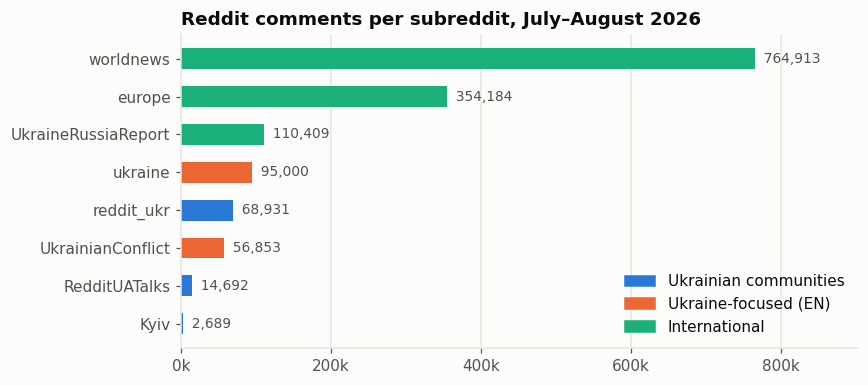

In [10]:
d = by_sub.sort_values("comments")
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(d.index, d["comments"], height=0.55, color=[SERIES[g] for g in d["group"]])
for y, v in enumerate(d["comments"]):
    ax.text(v, y, f"  {v:,}", va="center", color=INK_2, fontsize=9)
ax.set_title("Reddit comments per subreddit, July–August 2026")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))
ax.grid(axis="y", visible=False)
ax.set_xlim(0, d["comments"].max() * 1.18)
handles = [plt.Rectangle((0, 0), 1, 1, color=SERIES[g]) for g in GROUP_ORDER]
ax.legend(handles, GROUP_ORDER, frameon=False, loc="lower right")
fig.tight_layout(); fig.savefig(FIG / "reddit_comments_per_subreddit.png", dpi=200); plt.show()

### Kartonky: text source, date source, location

In [11]:
def vc(s, name):
    t = s.value_counts(dropna=False).rename("posters").to_frame()
    t["share"] = (t["posters"] / t["posters"].sum()).map("{:.1%}".format)
    t.index.name = name
    return t

display(vc(kartonky["text_source"], "text_source"))
display(vc(kartonky["date_source"], "date_source"))
display(vc(kartonky["location_group"], "location"))

,posters,share
text_source,,
unknown,3480,78.2%
user,711,16.0%
ocr,257,5.8%


,posters,share
date_source,,
upload_time,3499,78.7%
event_date,822,18.5%
exif,127,2.9%


,posters,share
location,,
Україна,3915,88.0%
невідомо,461,10.4%
за кордоном,72,1.6%


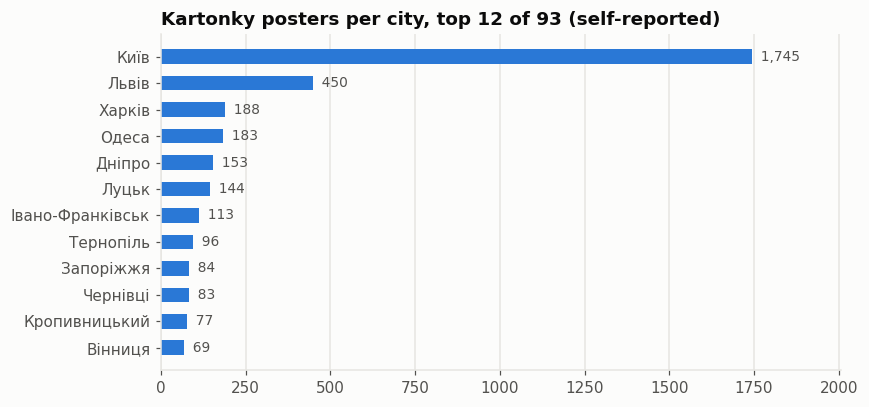

In [12]:
cities = kartonky["city_norm"].value_counts().head(12).sort_values()
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(cities.index, cities.values, height=0.55, color=ACCENT)
for y, v in enumerate(cities.values):
    ax.text(v, y, f"  {v:,}", va="center", color=INK_2, fontsize=9)
ax.set_title(f"Kartonky posters per city, top 12 of {kartonky['city_norm'].nunique()} (self-reported)")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, cities.max() * 1.15)
fig.tight_layout(); fig.savefig(FIG / "kartonky_top_cities.png", dpi=200); plt.show()

In [13]:
slogans = (kartonky[kartonky["has_text"]]
           .groupby("text_norm").agg(posters=("id", "size"), example=("text", "first"))
           .sort_values("posters", ascending=False).head(10).reset_index(drop=True))
slogans.index = slogans.index + 1
slogans

,posters,example
1,26,"Міняйте полонених, а не Федорова!"
2,13,СИРСЬКИЙ ЧОРТ
3,12,НАХУЯ МЕНІ система що працює ПРОТИ МЕНЕ!
4,12,Змінимось або загинемо
5,11,Нахіба мені система що працює проти мене
6,10,"Вибачте за незручності, ми тут змінюємо світ"
7,10,СИРСЬКОГО ГЕТЬ
8,9,Федорова вирніт.
9,9,Сирський - геть
10,7,Поверніть Федорова


### Activity per day (Kyiv time)

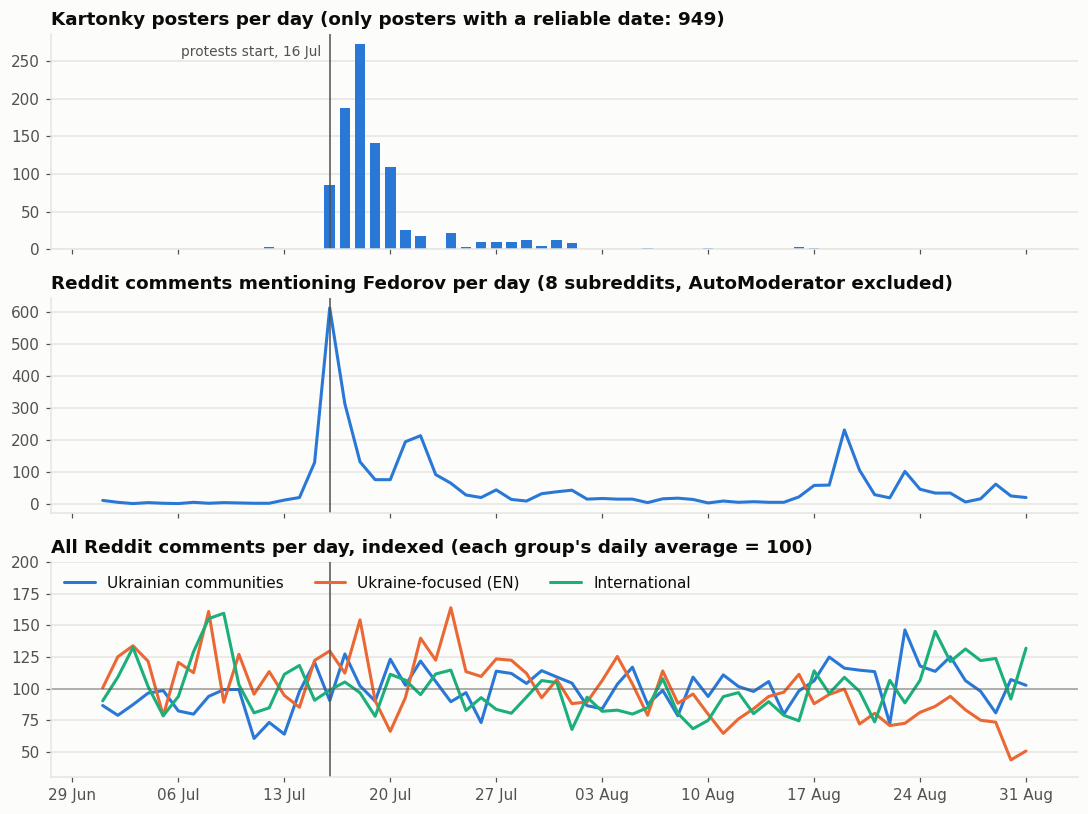

In [14]:
days = pd.date_range("2026-07-01", "2026-08-31", freq="D")
k_rel = (kartonky[kartonky["date_reliable"]]
         .assign(day=lambda x: pd.to_datetime(x["date_local"]))
         .groupby("day").size().reindex(days, fill_value=0))
fed = pd.Series({pd.Timestamp(k): v for k, v in fed_day.items()}).reindex(days, fill_value=0)
by_group = (pd.Series(per_day).rename_axis(["day", "group"]).rename("n").reset_index()
            .assign(day=lambda x: pd.to_datetime(x["day"]))
            .pivot_table(index="day", columns="group", values="n", aggfunc="sum")
            .reindex(days, fill_value=0))

fig, axes = plt.subplots(3, 1, figsize=(10, 7.5), sharex=True)
axes[0].bar(k_rel.index, k_rel.values, width=0.7, color=ACCENT)
axes[0].set_title(f"Kartonky posters per day (only posters with a reliable date: {int(k_rel.sum()):,})")
axes[1].plot(fed.index, fed.values, color=ACCENT)
axes[1].set_title("Reddit comments mentioning Fedorov per day (8 subreddits, AutoModerator excluded)")
# groups differ ~30x in volume, so index each to its own daily average (= 100) on one axis
indexed = by_group / by_group.mean() * 100
for g in GROUP_ORDER:
    axes[2].plot(indexed.index, indexed[g], color=SERIES[g], label=g)
axes[2].axhline(100, color=INK_2, linewidth=1, alpha=0.5)
axes[2].set_title("All Reddit comments per day, indexed (each group's daily average = 100)")
axes[2].set_ylim(30, 200)  # headroom so the legend never covers a line
axes[2].legend(frameon=False, ncols=3, loc="upper left")
for ax in axes:
    ax.axvline(PROTEST_START, color=INK_2, linewidth=1)
    ax.grid(axis="x", visible=False)
axes[0].text(PROTEST_START, axes[0].get_ylim()[1] * 0.9, "protests start, 16 Jul  ",
             color=INK_2, fontsize=9, ha="right")
axes[2].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
fig.tight_layout(); fig.savefig(FIG / "activity_per_day.png", dpi=200); plt.show()

In [15]:
window = pd.date_range("2026-07-13", "2026-07-24", freq="D")
pd.DataFrame({
    "Kartonky (reliable date)": k_rel.reindex(window),
    "Reddit comments mentioning Fedorov": fed.reindex(window),
    "Reddit comments, Ukrainian communities": by_group["Ukrainian communities"].reindex(window),
}).rename_axis("day (Kyiv)").rename(index=lambda d: d.strftime("%a %d %b"))

,Kartonky (reliable date),Reddit comments mentioning Fedorov,"Reddit comments, Ukrainian communities"
day (Kyiv),,,
Mon 13 Jul,0,11,891
Tue 14 Jul,0,19,1360
Wed 15 Jul,0,129,1680
Thu 16 Jul,86,614,1260
Fri 17 Jul,188,313,1772
Sat 18 Jul,272,131,1422
Sun 19 Jul,141,75,1254
Mon 20 Jul,110,75,1715
Tue 21 Jul,26,194,1428


## 6. What we collected and why it is useful

**Three views of one event.** The dataset joins an offline and an online trace of the July 2026 protests over Fedorov's dismissal. Kartonky gives 4,448 posters with their texts from 93 self-reported locations (88% in Ukraine, 1.6% abroad, 10% unknown; Kyiv alone is 39%, Lviv 10%). Reddit gives 34,424 submissions and 1,467,671 comments from 8 subreddits for July–August 2026: 1.23 GB after filtering the monthly dumps, 0.66 GB after cleaning. The subreddits cover three perspectives: Ukrainian communities (reddit_ukr, RedditUATalks, Kyiv), English-language Ukraine-focused (ukraine, UkrainianConflict) and international (worldnews, europe, UkraineRussiaReport).

**The event is visible in both worlds, with a lag.** Reddit comments mentioning Fedorov stay near 0–20 per day in early July, rise to 129 on 15 July, the day before the protests, and peak at 614 on 16 July. Then they fade, with a second wave on 21–22 July (~200/day) and another spike around 19 August (~230) that still needs explaining. Posters with a reliable date peak two days later, at 272 on 18 July, and the offline wave is mostly over by 21 July. Total comment volume, by contrast, barely moves around 16 July in any group (bottom panel): the event shows up in *what* people discuss, not in how much. This is the time structure the research question needs: online discussion, then posters on the same day and the following days, and later news can be aligned to the same daily axis.

**The texts already show themes.** The most repeated slogans connect the protest to specific decisions and people: "Міняйте полонених, а не Федорова" (26 identical posters, more as variants), "Поверніть Федорова", several against Syrskyi ("Сирський – геть", "СИРСЬКИЙ ЧОРТ") and a broader distrust ("система, що працює проти мене"). On Reddit, comment bodies, post titles (`link_title`) and user flairs (in r/europe often a country) give the online counterpart for keyword and sentiment comparison.

**Limitations to keep in the analysis.** Kartonky: for 78% of posters we don't know whether the text was typed by a person or read by OCR (the main wave, 16–20 July, came before the site started recording it). Only 949 posters (21%) have a reliable event date, the rest have only an upload time. The site stopped accepting uploads on 18 August because of a technical failure, and cities are self-reported. Reddit: international subreddits hold 84% of all comments, while Ukrainian communities hold ~6%, so groups must be compared by shares or indices, not raw counts. 11.7% of comments are removed or deleted (flagged, kept for activity counts), and 1.3% come from AutoModerator. The window is two months around the event rather than six.

**Next steps.** Add daily news for the same period, extract keywords from poster texts and Reddit comments for 15–20 July, compare sentiment across the three subreddit groups, and verify a sample of OCR texts (the archive author asked for corrections back).